In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import sys
from pathlib import Path

import torch
import torchvision.transforms as transforms

from PIL import Image
import matplotlib.pyplot as plt

In [13]:
from pathlib import Path
import zipfile

PROJECT_ROOT = Path("/content/drive/MyDrive/Capstone DDS")

ZIP_PATH = PROJECT_ROOT / "data" / "archive.zip"

EXTRACT_PATH = Path("/content/dataset")

if not (EXTRACT_PATH / "Dataset").exists():

    print("Extracting Dataset...")

    EXTRACT_PATH.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

    print("Dataset Extracted Successfully!")

else:

    print("Dataset Already Exists!")

DATASET = EXTRACT_PATH / "Dataset"

print(DATASET)

Extracting Dataset...
Dataset Extracted Successfully!
/content/dataset/Dataset


In [14]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Capstone DDS")

sys.path.insert(0, str(PROJECT_ROOT))

MODEL_DIR = PROJECT_ROOT / "models"

DATASET = Path("/content/dataset/Dataset")

print("Project Exists :", PROJECT_ROOT.exists())
print("Models Exists  :", MODEL_DIR.exists())
print("Dataset Exists :", DATASET.exists())

Project Exists : True
Models Exists  : True
Dataset Exists : True


In [15]:
from src.model import HybridDeepfakeDetector
from src.transforms import FrequencyTransform

print("Imports Successful!")

Imports Successful!


In [16]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*50)
print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

print("="*50)

Device : cuda
GPU : Tesla T4


In [17]:
device = torch.device("cpu")
import torchvision.transforms as transforms

IMAGE_SIZE = 224

rgb_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

frequency_transform = transforms.Compose([
    FrequencyTransform(),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print("Transforms Ready!")
print(device)

Transforms Ready!
cpu


In [18]:
MODEL_PATH = PROJECT_ROOT / "models" / "best_model.pth"

model = HybridDeepfakeDetector(
    pretrained=False
).to(device)

state_dict = torch.load(
    MODEL_PATH,
    map_location=device
)

model.load_state_dict(state_dict)

model.eval()

print("="*50)
print("Model Loaded Successfully!")
print("Model Path :", MODEL_PATH)
print("="*50)

Model Loaded Successfully!
Model Path : /content/drive/MyDrive/Capstone DDS/models/best_model.pth


In [19]:
from PIL import Image

def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    rgb = rgb_transform(image).unsqueeze(0).to(device)

    freq = frequency_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(rgb, freq)

        probabilities = torch.softmax(outputs, dim=1)

        prediction = outputs.argmax(1).item()

    confidence = probabilities[0][prediction].item()

    label = "Real" if prediction == 0 else "Fake"

    return label, confidence

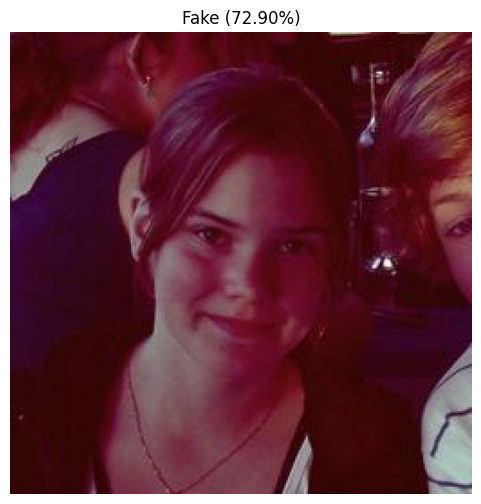

Prediction : Fake
Confidence : 0.7289624214172363


In [20]:
import matplotlib.pyplot as plt

sample = sorted((DATASET/"Test"/"Real").glob("*"))[0]

label, confidence = predict_image(sample)

plt.figure(figsize=(6,6))
plt.imshow(Image.open(sample))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

print("Prediction :", label)
print("Confidence :", confidence)

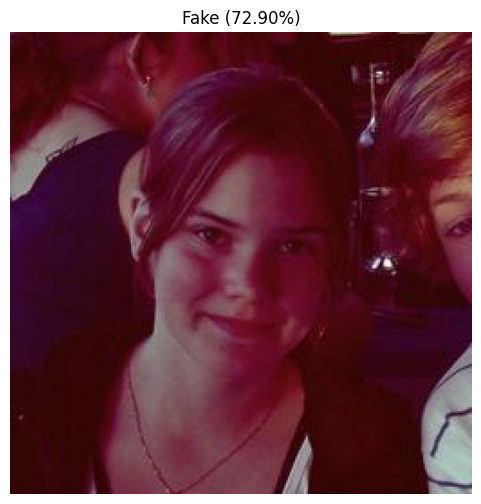

Prediction : Fake
Confidence : 0.7289624214172363


In [21]:
import matplotlib.pyplot as plt

sample = sorted((DATASET/"Test"/"Real").glob("*"))[0]

label, confidence = predict_image(sample)

plt.figure(figsize=(6,6))
plt.imshow(Image.open(sample))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

print("Prediction :", label)
print("Confidence :", confidence)

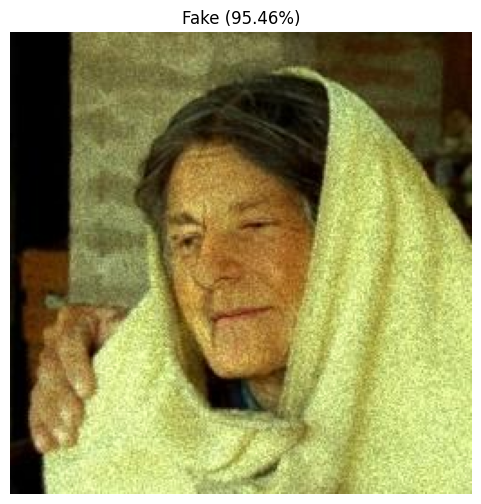

Prediction : Fake
Confidence : 0.9546334743499756


In [22]:
sample = sorted((DATASET/"Test"/"Fake").glob("*"))[0]

label, confidence = predict_image(sample)

plt.figure(figsize=(6,6))
plt.imshow(Image.open(sample))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

print("Prediction :", label)
print("Confidence :", confidence)

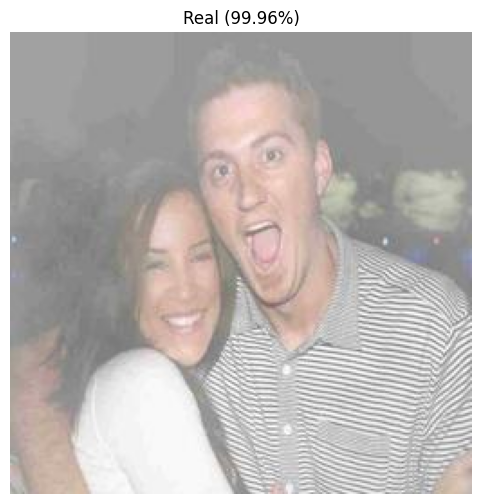

Actual Folder : Real
Prediction    : Real
Confidence    : 99.96%


In [23]:
import random

all_images = []

all_images.extend(list((DATASET/"Test"/"Real").glob("*")))
all_images.extend(list((DATASET/"Test"/"Fake").glob("*")))

sample = random.choice(all_images)

label, confidence = predict_image(sample)

plt.figure(figsize=(6,6))
plt.imshow(Image.open(sample))
plt.axis("off")
plt.title(f"{label} ({confidence*100:.2f}%)")
plt.show()

print("Actual Folder :", sample.parent.name)
print("Prediction    :", label)
print("Confidence    :", f"{confidence*100:.2f}%")